Loading dataset and establishing Ground Truth...
Ground Truth established with 16714 complete records.

APPROACH 1: IMPUTATION QUALITY (NRMSE Evaluation)

Injecting 10% MCAR missing data...
  [Mean] NRMSE: 0.8148
  [Median] NRMSE: 0.8449
  [KNN] NRMSE: 0.6108
  [SHD] NRMSE: 1.2706
  [MissForest] NRMSE: 0.6597
  [MICE] NRMSE: 0.5303

Injecting 20% MCAR missing data...
  [Mean] NRMSE: 1.0625
  [Median] NRMSE: 1.0953
  [KNN] NRMSE: 0.9476
  [SHD] NRMSE: 1.5311
  [MissForest] NRMSE: 0.9548
  [MICE] NRMSE: 0.8469

Injecting 30% MCAR missing data...
  [Mean] NRMSE: 0.9600
  [Median] NRMSE: 0.9921
  [KNN] NRMSE: 0.9443
  [SHD] NRMSE: 1.2825
  [MissForest] NRMSE: 0.8139
  [MICE] NRMSE: 0.9594

Injecting 40% MCAR missing data...
  [Mean] NRMSE: 0.9757
  [Median] NRMSE: 1.0076
  [KNN] NRMSE: 1.0302
  [SHD] NRMSE: 1.3947
  [MissForest] NRMSE: 0.8348
  [MICE] NRMSE: 0.9351

Injecting 50% MCAR missing data...
  [Mean] NRMSE: 0.9953
  [Median] NRMSE: 1.0277
  [KNN] NRMSE: 1.0734
  [SHD] NRMSE: 1.404

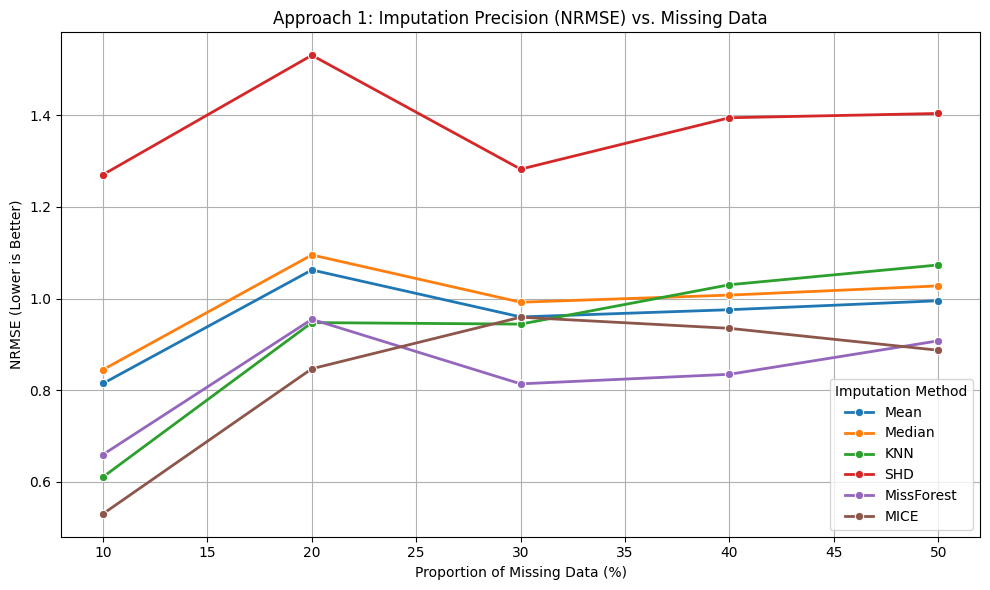

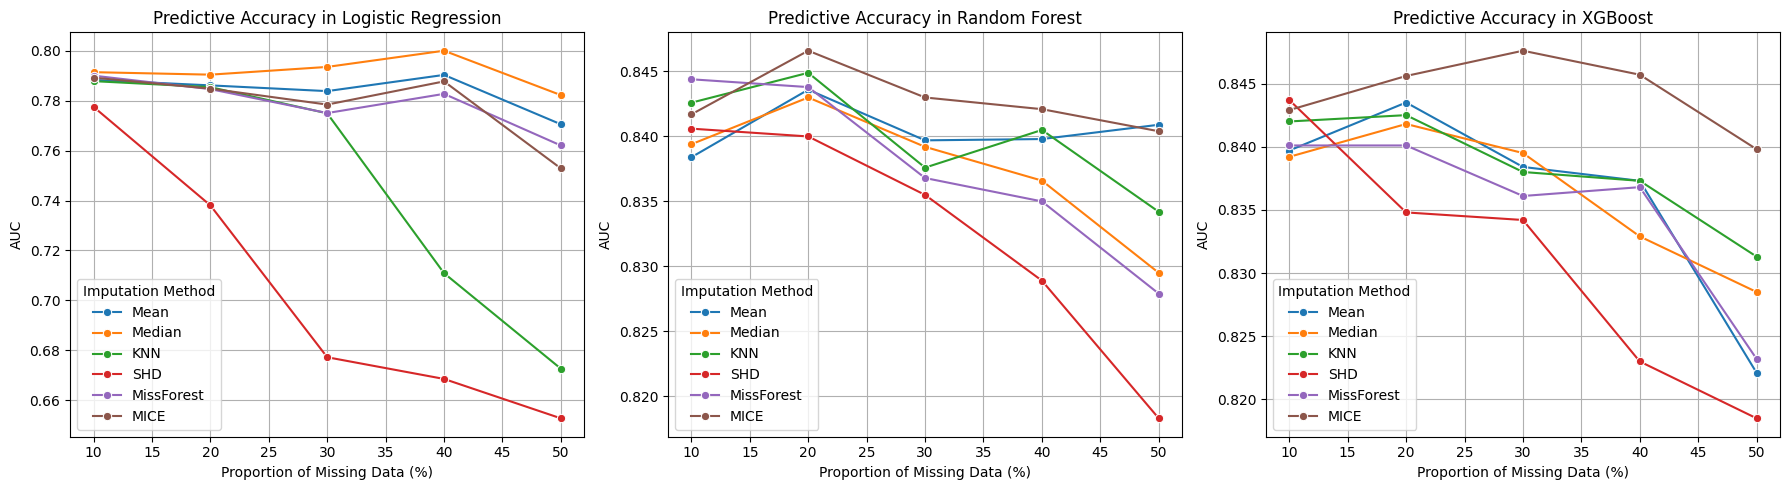

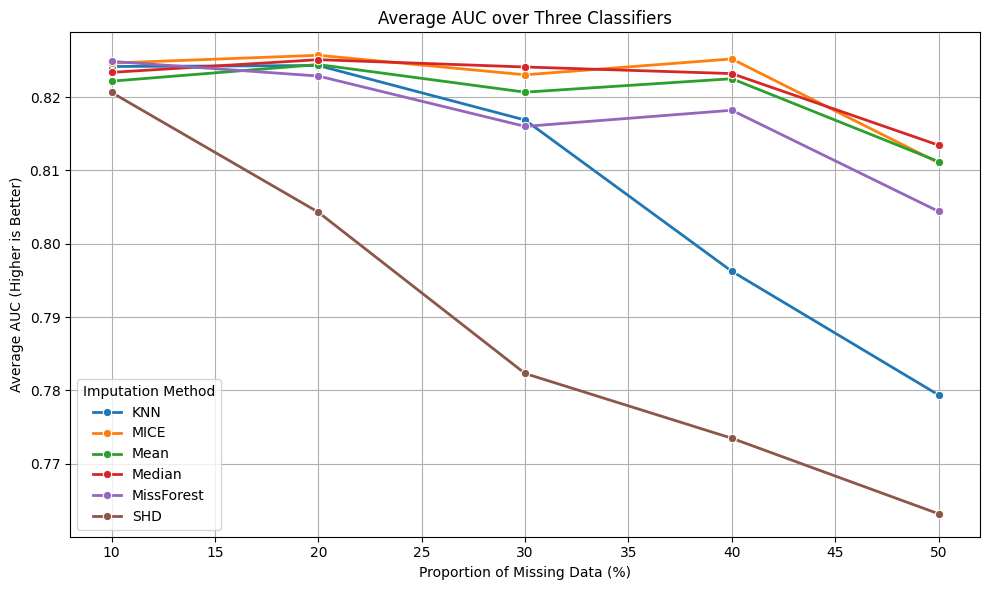


FINAL RESULTS: APPROACH 1 (Imputation Precision)
Imputation Method          KNN    MICE    Mean  Median  MissForest     SHD
Missing Proportion (%)                                                    
10                      0.6108  0.5303  0.8148  0.8449      0.6597  1.2706
20                      0.9476  0.8469  1.0625  1.0953      0.9548  1.5311
30                      0.9443  0.9594  0.9600  0.9921      0.8139  1.2825
40                      1.0302  0.9351  0.9757  1.0076      0.8348  1.3947
50                      1.0734  0.8873  0.9953  1.0277      0.9078  1.4041

FINAL RESULTS: APPROACH 2 (Predictive Integrity - AUC)
Imputation Method            KNN      MICE      Mean    Median  MissForest  \
Missing Proportion (%)                                                       
10                      0.824167  0.824633  0.822167  0.823367    0.824867   
20                      0.824300  0.825700  0.824433  0.825100    0.822867   
30                      0.816867  0.823033  0.820667  0.8

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer  # Required to enable IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import BayesianRidge, LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output during iterative imputation and linear model convergence
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# Configuration & Global Variables
# ---------------------------------------------------------
FILE_PATH = "../data/Credit Risk Benchmark Dataset.csv"
TARGET_COL = 'dlq_2yrs'
PROPORTIONS = [0.1, 0.2, 0.3, 0.4, 0.5]
RANDOM_STATE = 42

# ---------------------------------------------------------
# Helper Functions
# ---------------------------------------------------------
def load_ground_truth(filepath, target_col):
    """Loads dataset and drops any existing NaNs to establish Ground Truth."""
    print("Loading dataset and establishing Ground Truth...")
    df = pd.read_csv(filepath)
    # Drop rows with any NaNs to create the perfect baseline N = 16,714
    df_clean = df.dropna().reset_index(drop=True)
    print(f"Ground Truth established with {len(df_clean)} complete records.\n")
    return df_clean

def inject_mcar(df, proportion, target_col):
    """
    Injects Missing Completely at Random (MCAR) data into the DataFrame.
    The target column is excluded from corruption.
    """
    df_missing = df.copy()
    features = [col for col in df.columns if col != target_col]
    
    # Mask to keep track of exactly where we put NaNs
    mask = pd.DataFrame(False, index=df.index, columns=df.columns)
    
    for col in features:
        # Determine number of missing values to inject per column
        n_missing = int(len(df) * proportion)
        
        # Randomly select indices to corrupt
        missing_indices = np.random.choice(df.index, n_missing, replace=False)
        
        # Inject NaNs
        df_missing.loc[missing_indices, col] = np.nan
        mask.loc[missing_indices, col] = True
        
    return df_missing, mask

def apply_imputation(df_missing, method):
    """
    Applies the selected imputation algorithm to the dataframe.
    """
    df_imputed = df_missing.copy()
    features = [col for col in df_imputed.columns if col != TARGET_COL]
    
    if method == 'Mean':
        imputer = SimpleImputer(strategy='mean')
        df_imputed[features] = imputer.fit_transform(df_imputed[features])
        
    elif method == 'Median':
        imputer = SimpleImputer(strategy='median')
        df_imputed[features] = imputer.fit_transform(df_imputed[features])
        
    elif method == 'KNN':
        # MAJOR FIX: KNN distance calculations are heavily skewed by unscaled financial data 
        # (e.g., Income vs. Ratio). We must standardize before imputing, then inverse transform.
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_imputed[features])
        imputer = KNNImputer(n_neighbors=5)
        imputed_scaled = imputer.fit_transform(scaled_features)
        df_imputed[features] = scaler.inverse_transform(imputed_scaled)
        
    elif method == 'SHD':
        # Sequential Hot-Deck: simulated using forward fill, then backward fill for edge cases
        df_imputed[features] = df_imputed[features].ffill().bfill()
        
    elif method == 'MissForest':
        # MissForest is mathematically an IterativeImputer utilizing Random Forests
        imputer = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1),
            max_iter=5, random_state=RANDOM_STATE
        )
        df_imputed[features] = imputer.fit_transform(df_imputed[features])
        
    elif method == 'MICE':
        # MAJOR FIX: Bayesian Ridge is a linear model sensitive to scale.
        # Standardizing prevents large-magnitude features from dominating the ridge penalty.
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(df_imputed[features])
        imputer = IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=10, random_state=RANDOM_STATE
        )
        imputed_scaled = imputer.fit_transform(scaled_features)
        df_imputed[features] = scaler.inverse_transform(imputed_scaled)
        
    return df_imputed

def calculate_nrmse(df_true, df_imputed, mask):
    """
    Calculates the Normalized Root Mean Squared Error (NRMSE) 
    only on the artificially injected missing cells.
    """
    features = [col for col in df_true.columns if col != TARGET_COL]
    
    nrmse_list = []
    for col in features:
        # Extract only the indices where we injected NaNs
        missing_idx = mask[mask[col] == True].index
        
        if len(missing_idx) == 0:
            continue
            
        y_true = df_true.loc[missing_idx, col]
        y_pred = df_imputed.loc[missing_idx, col]
        
        # Standard RMSE
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        # Normalize by standard deviation of the true column
        std_val = df_true[col].std()
        nrmse = rmse / std_val if std_val > 0 else 0
        nrmse_list.append(nrmse)
        
    return np.mean(nrmse_list)

# ---------------------------------------------------------
# Workflow Approach 1: Imputation Quality
# ---------------------------------------------------------
def run_approach_1(df_ground_truth):
    print("="*60)
    print("APPROACH 1: IMPUTATION QUALITY (NRMSE Evaluation)")
    print("="*60)
    
    imputation_methods = ['Mean', 'Median', 'KNN', 'SHD', 'MissForest', 'MICE']
    results = []
    
    for prop in PROPORTIONS:
        print(f"\nInjecting {int(prop*100)}% MCAR missing data...")
        df_missing, mask = inject_mcar(df_ground_truth, prop, TARGET_COL)
        
        for method in imputation_methods:
            df_imputed = apply_imputation(df_missing, method)
            nrmse = calculate_nrmse(df_ground_truth, df_imputed, mask)
            
            results.append({
                'Missing Proportion (%)': int(prop*100),
                'Imputation Method': method,
                'NRMSE (Lower is better)': round(nrmse, 4)
            })
            print(f"  [{method}] NRMSE: {nrmse:.4f}")
            
    return pd.DataFrame(results)

# ---------------------------------------------------------
# Workflow Approach 2: Predictive Integrity
# ---------------------------------------------------------
def run_approach_2(df_ground_truth):
    print("\n" + "="*60)
    print("APPROACH 2: PREDICTIVE INTEGRITY (Downstream AUC Evaluation)")
    print("="*60)
    
    imputation_methods = ['Mean', 'Median', 'KNN', 'SHD', 'MissForest', 'MICE']
    
    # Define Classifiers
    # FIX: Removed `use_label_encoder=False` as it is deprecated and causes errors in modern XGBoost (>=2.0)
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
    }
    
    results = []
    
    # Train / Test Split (70/30)
    # The Test set remains perfectly pristine/clean throughout the experiment
    train_df, test_df = train_test_split(df_ground_truth, test_size=0.3, random_state=RANDOM_STATE, stratify=df_ground_truth[TARGET_COL])
    
    X_test = test_df.drop(columns=[TARGET_COL])
    y_test = test_df[TARGET_COL]
    
    # Scale test set for Logistic Regression consistency
    scaler = StandardScaler()
    
    for prop in PROPORTIONS:
        print(f"\nInjecting {int(prop*100)}% MCAR missing data into Train Set...")
        train_missing, _ = inject_mcar(train_df, prop, TARGET_COL)
        y_train = train_missing[TARGET_COL]
        
        for method in imputation_methods:
            # Impute the corrupted Train set
            train_imputed = apply_imputation(train_missing, method)
            X_train_imputed = train_imputed.drop(columns=[TARGET_COL])
            
            for clf_name, clf in classifiers.items():
                
                # Scale data specifically for Linear Models
                if clf_name == 'Logistic Regression':
                    X_train_scaled = scaler.fit_transform(X_train_imputed)
                    X_test_scaled = scaler.transform(X_test)
                    clf.fit(X_train_scaled, y_train)
                    y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
                else:
                    clf.fit(X_train_imputed, y_train)
                    y_pred_proba = clf.predict_proba(X_test)[:, 1]
                
                # Evaluate on pristine test set
                auc = roc_auc_score(y_test, y_pred_proba)
                
                results.append({
                    'Missing Proportion (%)': int(prop*100),
                    'Imputation Method': method,
                    'Classifier': clf_name,
                    'AUC': round(auc, 4)
                })
            
            print(f"  [{method}] Models trained & evaluated.")

    return pd.DataFrame(results)

# ---------------------------------------------------------
# Visualization Functions
# ---------------------------------------------------------
def plot_approach_1(df_results):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_results, x='Missing Proportion (%)', y='NRMSE (Lower is better)', hue='Imputation Method', marker='o', linewidth=2)
    plt.title('Approach 1: Imputation Precision (NRMSE) vs. Missing Data')
    plt.xlabel('Proportion of Missing Data (%)')
    plt.ylabel('NRMSE (Lower is Better)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('approach1_nrmse_plot.png')
    plt.show()

def plot_approach_2(df_results):
    # 1. Plot individual classifiers
    classifiers = df_results['Classifier'].unique()
    fig, axes = plt.subplots(1, len(classifiers), figsize=(18, 5), sharey=False)
    
    for i, clf in enumerate(classifiers):
        sns.lineplot(data=df_results[df_results['Classifier'] == clf], 
                     x='Missing Proportion (%)', y='AUC', hue='Imputation Method', 
                     marker='o', ax=axes[i])
        axes[i].set_title(f'Predictive Accuracy in {clf}')
        axes[i].set_xlabel('Proportion of Missing Data (%)')
        axes[i].set_ylabel('AUC')
        axes[i].grid(True)
        
    plt.tight_layout()
    plt.savefig('approach2_classifiers_auc.png')
    plt.show()
    
    # 2. Plot Average AUC across all classifiers
    avg_df = df_results.groupby(['Missing Proportion (%)', 'Imputation Method'])['AUC'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=avg_df, x='Missing Proportion (%)', y='AUC', hue='Imputation Method', marker='o', linewidth=2)
    plt.title('Average AUC over Three Classifiers')
    plt.xlabel('Proportion of Missing Data (%)')
    plt.ylabel('Average AUC (Higher is Better)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('approach2_average_auc.png')
    plt.show()

# ---------------------------------------------------------
# Main Execution Block
# ---------------------------------------------------------
if __name__ == "__main__":
    try:
        # 1. Establish Ground Truth Baseline
        df_ground_truth = load_ground_truth(FILE_PATH, TARGET_COL)
        
        # 2. Run Approach 1
        results_approach_1 = run_approach_1(df_ground_truth)
        
        # 3. Run Approach 2
        results_approach_2 = run_approach_2(df_ground_truth)
        
        # 4. Generate Visualizations
        print("\nGenerating visualizations...")
        plot_approach_1(results_approach_1)
        plot_approach_2(results_approach_2)
        
        # 5. Final Output Summaries
        print("\n" + "="*60)
        print("FINAL RESULTS: APPROACH 1 (Imputation Precision)")
        print("="*60)
        # Pivot table for better readability
        pivot_1 = results_approach_1.pivot(index='Missing Proportion (%)', columns='Imputation Method', values='NRMSE (Lower is better)')
        print(pivot_1)
        
        print("\n" + "="*60)
        print("FINAL RESULTS: APPROACH 2 (Predictive Integrity - AUC)")
        print("="*60)
        # Group by missing proportion and imputer, taking the mean AUC across the 3 classifiers
        pivot_2 = results_approach_2.groupby(['Missing Proportion (%)', 'Imputation Method'])['AUC'].mean().unstack()
        print(pivot_2)
        print("\n* Note: Values shown in Approach 2 are the mean AUC across LR, RF, and XGBoost.")
        print("Workflow execution completed successfully.")
        
    except FileNotFoundError:
        print(f"Error: Could not find the dataset at '{FILE_PATH}'. Please ensure the file is in the same directory as this script.")